
[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
(100000, 18)
obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class              str
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object
         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i  

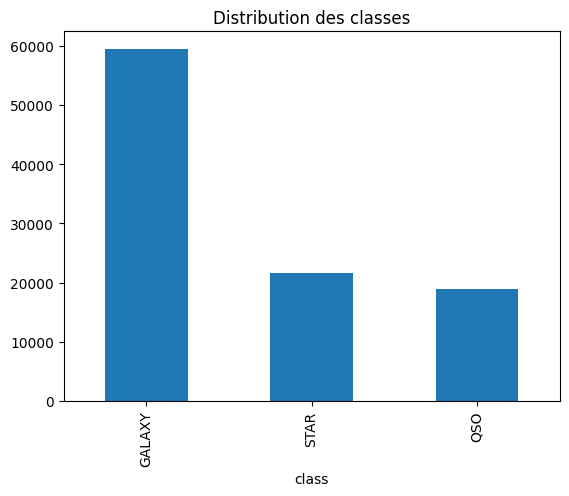

La description statistique des données:
             obj_ID          alpha          delta              u  \
count  1.000000e+05  100000.000000  100000.000000  100000.000000   
mean   1.237665e+18     177.629117      24.135305      21.980468   
std    8.438560e+12      96.502241      19.644665      31.769291   
min    1.237646e+18       0.005528     -18.785328   -9999.000000   
25%    1.237659e+18     127.518222       5.146771      20.352353   
50%    1.237663e+18     180.900700      23.645922      22.179135   
75%    1.237668e+18     233.895005      39.901550      23.687440   
max    1.237681e+18     359.999810      83.000519      32.781390   

                   g              r              i              z  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean       20.531387      19.645762      19.084854      18.668810   
std        31.750292       1.854760       1.757895      31.728152   
min     -9999.000000       9.822070       9.469903   -9999.000000   
25

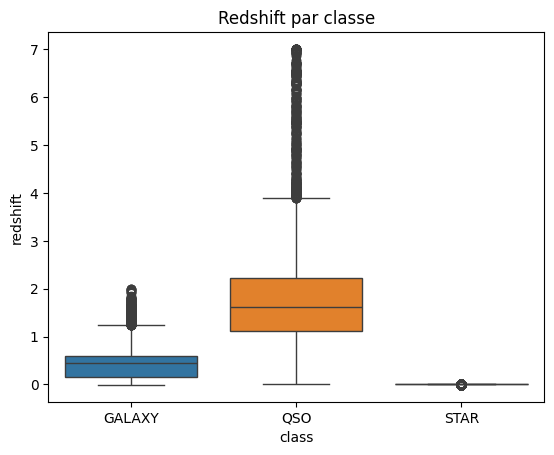

Colonnes qui ne sont pas utiles pour la classification: ['obj_ID', 'rerun_ID', 'run_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
Colonnes restantes: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']
Shape après nettoyage: (100000, 9)
        alpha      delta         u         g         r         i         z  \
0  135.689107  32.494632  23.87882  22.27530  20.39501  19.16573  18.79371   
1  144.826101  31.274185  24.77759  22.83188  22.58444  21.16812  21.61427   
2  142.188790  35.582444  25.26307  22.66389  20.60976  19.34857  18.94827   
3  338.741038  -0.402828  22.13682  23.77656  21.61162  20.50454  19.25010   
4  345.282593  21.183866  19.43718  17.58028  16.49747  15.97711  15.54461   

    class  redshift  
0  GALAXY  0.634794  
1  GALAXY  0.779136  
2  GALAXY  0.644195  
3  GALAXY  0.932346  
4  GALAXY  0.116123  


In [5]:
# Cellule 0 — Installation des dépendances (à exécuter une seule fois)
import sys
!{sys.executable} -m pip install scikit-learn imbalanced-learn --quiet
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Shift 1 --- Brice 
df = pd.read_csv("star_classification.csv")

# Shape et types
print(df.shape)
print(df.dtypes)
print(df.head())
# Valeurs manquantes
print("Les valeurs manquantes:", df.isnull().sum(), " #fin des valeurs manquantes")


# Distribution des classes
print("Distribution des classes:")
print(df['class'].value_counts())
df['class'].value_counts().plot(kind='bar')
plt.title("Distribution des classes")
plt.show()

# Statistiques descriptives
print("La description statistique des données:")
print(df.describe())

# Distribution du redshift par classe
# avant : sns.boxplot(x='class', y='redshift', data=df)
sns.boxplot(x='class', y='redshift', data=df, hue='class', legend=False)
plt.title("Redshift par classe")
plt.show()

# La supression des colonnes inutiles
colonnes_a_supprimer = ['obj_ID', 'rerun_ID', 'run_ID', 'cam_col', 
                    'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
print("Colonnes qui ne sont pas utiles pour la classification:", colonnes_a_supprimer)

df = df.drop(columns=colonnes_a_supprimer)

print("Colonnes restantes:", df.columns.tolist())
print("Shape après nettoyage:", df.shape)

print(df.head())



Shape après feature engineering: (100000, 13)
Nouvelles colonnes: ['u-g', 'g-r', 'r-i', 'i-z']
                 u-g            g-r            r-i            i-z
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        1.449081       0.885625       0.560908       0.416044
std         1.179335      31.688694       0.501517      31.678379
min       -12.748140  -10017.165600     -14.649070     -13.162490
25%         0.631215       0.379798       0.216317       0.134500
50%         1.321670       0.931450       0.479795       0.338040
75%         2.044558       1.577983       0.892192       0.474080
max        18.624950      14.315170      12.205800   10017.016750


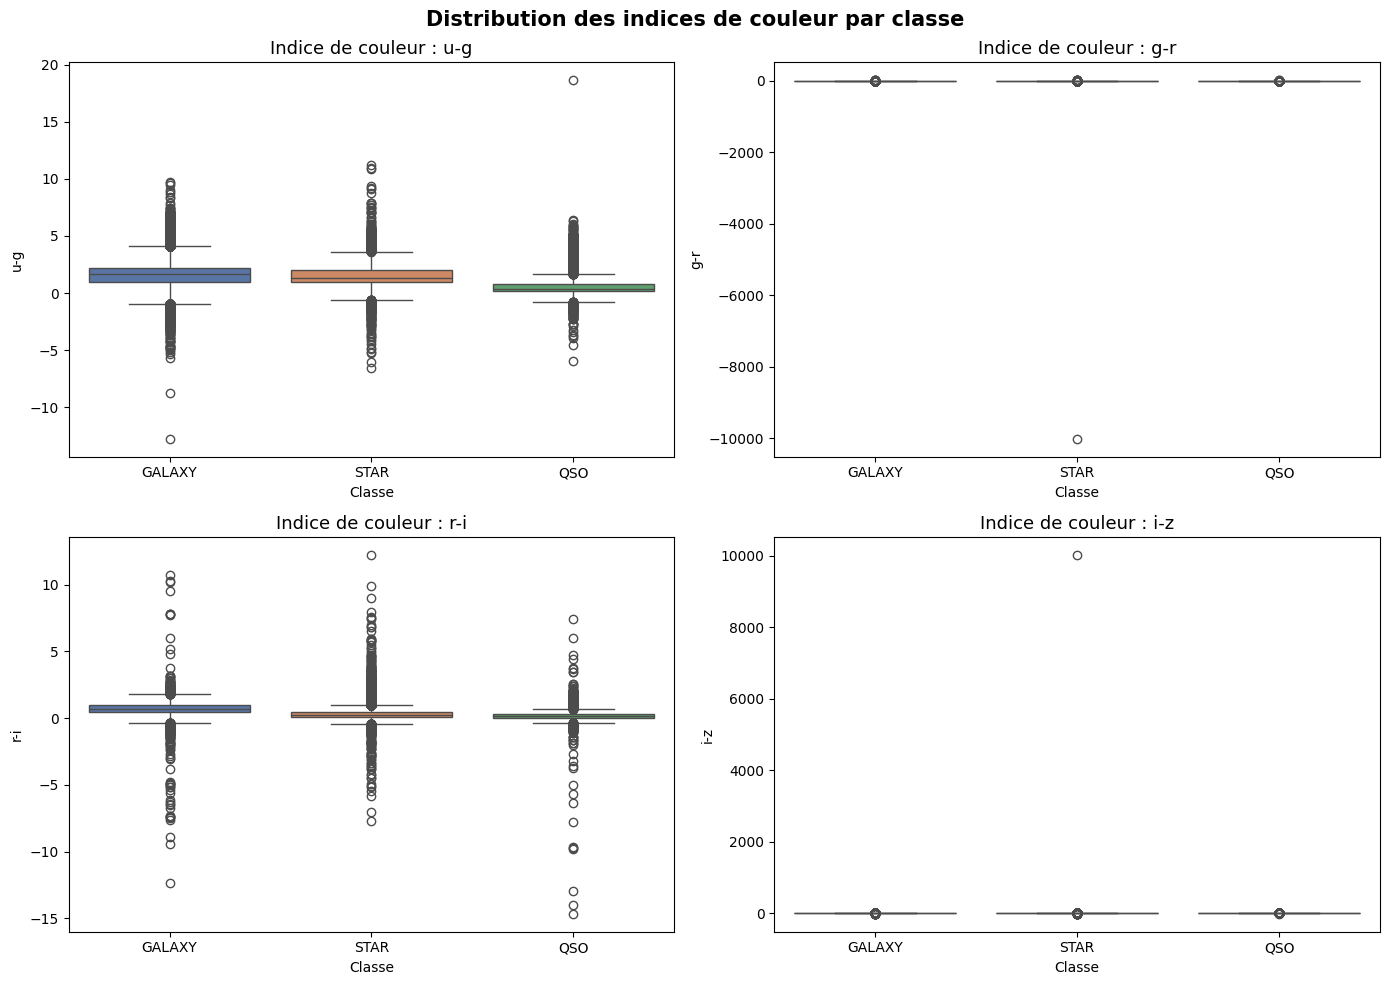

→ Boxplots des indices de couleur enregistrés.


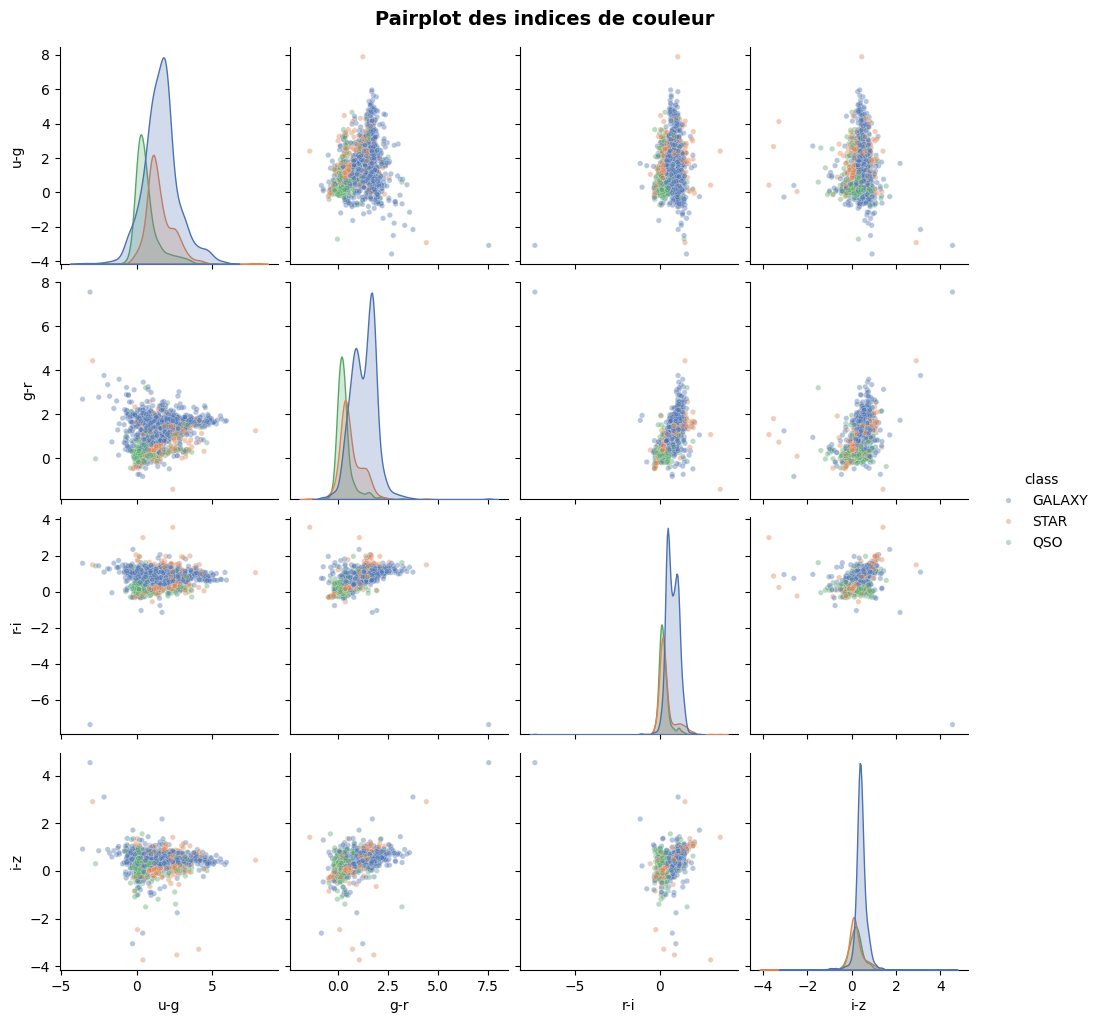

→ Pairplot enregistré.


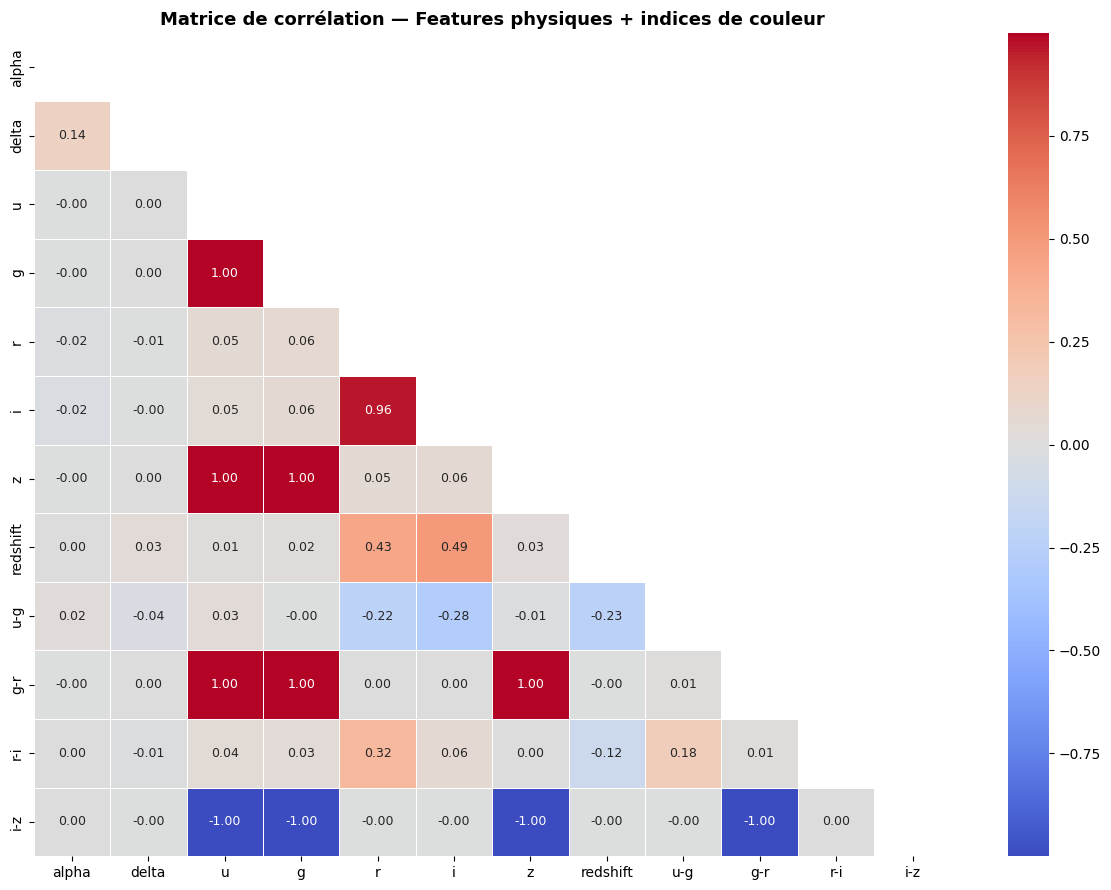

→ Heatmap de corrélation enregistrée.

Encodage des classes:
  GALAXY → 0
  QSO → 1
  STAR → 2

X shape : (100000, 12)
y distribution avant SMOTE :
class_encoded
0    59445
2    21594
1    18961
Name: count, dtype: int64

Train : 80000 observations
Test  : 20000 observations

Normalisation appliquée (fit sur train uniquement).
Moyenne train (doit être ≈0) : [ 0. -0. -0.  0. -0. -0.  0. -0.  0.  0. -0. -0.]
Écart-type train (doit être ≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Distribution avant SMOTE :
class_encoded
0    47556
2    17275
1    15169
Name: count, dtype: int64
Distribution après SMOTE  :
class_encoded
1    47556
2    47556
0    47556
Name: count, dtype: int64
Shape final X_train : (142668, 12)


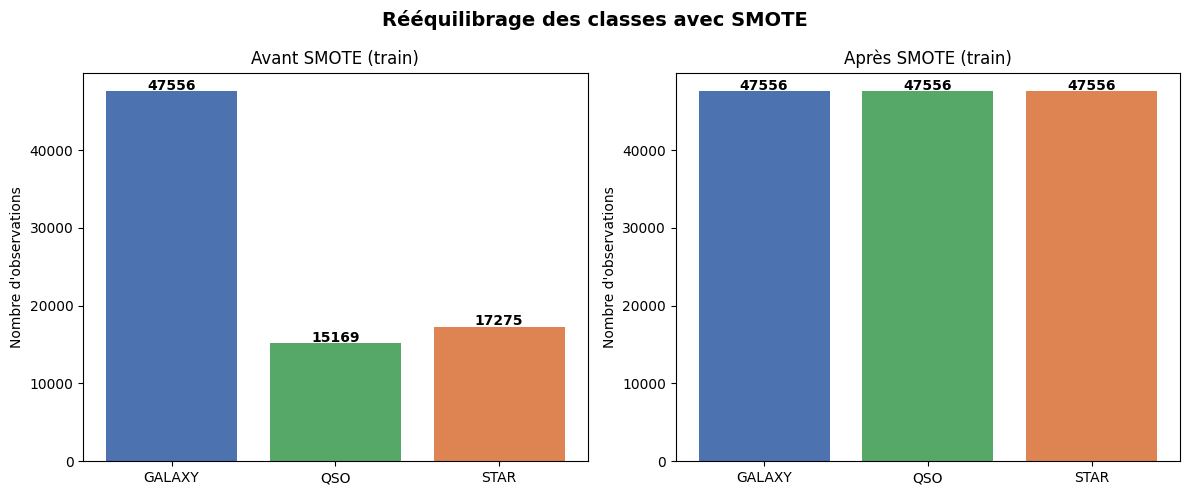

→ Graphique SMOTE enregistré.

✅  SPRINT 1 — Données prêtes pour la modélisation
  Features utilisées    : ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'u-g', 'g-r', 'r-i', 'i-z']
  X_train (post-SMOTE)  : (142668, 12)
  X_test  (non rééch.)  : (20000, 12)
  Classes encodées      : {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


In [6]:


# Shift 1 --- Sarah T
# ============================================================
# Feature Engineering & Préparation finale du dataset
# ============================================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# --- 1. Création des indices de couleur (déjà amorcée) ---
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

print("Shape après feature engineering:", df.shape)
print("Nouvelles colonnes:", ['u-g', 'g-r', 'r-i', 'i-z'])
print(df[['u-g', 'g-r', 'r-i', 'i-z']].describe())

# --- 2. Visualisation des indices de couleur par classe ---
color_features = ['u-g', 'g-r', 'r-i', 'i-z']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(color_features):
    sns.boxplot(x='class', y=feat, data=df, ax=axes[i],
                order=['GALAXY', 'STAR', 'QSO'],
                hue='class',
                palette={'GALAXY': '#4C72B0', 'STAR': '#DD8452', 'QSO': '#55A868'},
                legend=False)
    axes[i].set_title(f"Indice de couleur : {feat}", fontsize=13)
    axes[i].set_xlabel("Classe")
    axes[i].set_ylabel(feat)

plt.suptitle("Distribution des indices de couleur par classe", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("color_indices_boxplots.png", dpi=150)
plt.show()
print("→ Boxplots des indices de couleur enregistrés.")

# --- 3. Pairplot pour visualiser la séparabilité ---
sample = df.sample(2000, random_state=42)  # sous-échantillon pour la lisibilité

sns.pairplot(
    sample[color_features + ['class']],
    hue='class',
    hue_order=['GALAXY', 'STAR', 'QSO'],
    palette={'GALAXY': '#4C72B0', 'STAR': '#DD8452', 'QSO': '#55A868'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)
plt.suptitle("Pairplot des indices de couleur", y=1.02, fontsize=14, fontweight='bold')
plt.savefig("color_indices_pairplot.png", dpi=120)
plt.show()
print("→ Pairplot enregistré.")

# --- 4. Heatmap de corrélation (features complètes) ---
features_for_corr = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z',
                     'redshift', 'u-g', 'g-r', 'r-i', 'i-z']

plt.figure(figsize=(12, 9))
corr = df[features_for_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={"size": 9})
plt.title("Matrice de corrélation — Features physiques + indices de couleur",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("→ Heatmap de corrélation enregistrée.")

# --- 5. Encodage de la variable cible ---
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])
print("\nEncodage des classes:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {code}")

# --- 6. Séparation features / cible ---
feature_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z',
                'redshift', 'u-g', 'g-r', 'r-i', 'i-z']

X = df[feature_cols]
y = df['class_encoded']

print(f"\nX shape : {X.shape}")
print(f"y distribution avant SMOTE :\n{pd.Series(y).value_counts()}")

# --- 7. Split stratifié 80/20 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\nTrain : {X_train.shape[0]} observations")
print(f"Test  : {X_test.shape[0]} observations")

# --- 8. Normalisation (StandardScaler sur le train, appliqué sur le test) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nNormalisation appliquée (fit sur train uniquement).")
print(f"Moyenne train (doit être ≈0) : {X_train_scaled.mean(axis=0).round(4)}")
print(f"Écart-type train (doit être ≈1): {X_train_scaled.std(axis=0).round(4)}")

# --- 9. Application de SMOTE (sur le train uniquement) ---
print(f"\nDistribution avant SMOTE :\n{pd.Series(y_train).value_counts()}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Distribution après SMOTE  :\n{pd.Series(y_train_resampled).value_counts()}")
print(f"Shape final X_train : {X_train_resampled.shape}")

# --- 10. Visualisation SMOTE avant/après ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_names = le.classes_
counts_before = pd.Series(y_train).value_counts().sort_index()
counts_after  = pd.Series(y_train_resampled).value_counts().sort_index()
colors = ['#4C72B0', '#55A868', '#DD8452']

axes[0].bar(class_names, counts_before, color=colors)
axes[0].set_title("Avant SMOTE (train)", fontsize=12)
axes[0].set_ylabel("Nombre d'observations")
for j, v in enumerate(counts_before):
    axes[0].text(j, v + 200, str(v), ha='center', fontweight='bold')

axes[1].bar(class_names, counts_after, color=colors)
axes[1].set_title("Après SMOTE (train)", fontsize=12)
axes[1].set_ylabel("Nombre d'observations")
for j, v in enumerate(counts_after):
    axes[1].text(j, v + 200, str(v), ha='center', fontweight='bold')

plt.suptitle("Rééquilibrage des classes avec SMOTE", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("smote_distribution.png", dpi=150)
plt.show()
print("→ Graphique SMOTE enregistré.")

# --- 11. Récapitulatif final ---
print("\n" + "="*55)
print("✅  SPRINT 1 — Données prêtes pour la modélisation")
print("="*55)
print(f"  Features utilisées    : {feature_cols}")
print(f"  X_train (post-SMOTE)  : {X_train_resampled.shape}")
print(f"  X_test  (non rééch.)  : {X_test_scaled.shape}")
print(f"  Classes encodées      : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("="*55)


In [7]:
# ÉTAPE 1 — Baseline Random Forest (sans tuning)

rrf_baseline = RandomForestClassifier(
    # Nombre d'arbres dans la forêt
    n_estimators=100,
    # Graine pour la reproductibilité
    random_state=42,
    # Utilise tous les coeurs 
    n_jobs=-1
)

rf_baseline.fit(X_train_resampled, y_train_resampled)

# Score sur le test set (données jamais vues)
baseline_score = rf_baseline.score(X_test_scaled, y_test)
print(f"Accuracy baseline (sans tuning) : {baseline_score:.4f}")

# ÉTAPE 2 — Grid Search pour optimiser les hyperparamètres
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

print(f"\nNombre de combinaisons à tester : {3*3*2*2}")

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=8,
    verbose=2,
    scoring='accuracy'
)

import joblib
import os

model_path    = "best_rf_model.pkl"
meta_path     = "best_rf_meta.pkl"

if os.path.exists(model_path) and os.path.exists(meta_path):
    print("✅ Modèle chargé depuis le fichier (pas de réentraînement)")
    best_rf = joblib.load(model_path)
    meta    = joblib.load(meta_path)

else:
    print("⏳ Grid Search en cours (peut prendre quelques minutes)...")
    grid_search.fit(X_train_resampled, y_train_resampled)
    best_rf = grid_search.best_estimator_

    # Sauvegarde du modèle
    joblib.dump(best_rf, model_path)

    # Sauvegarde des métadonnées
    joblib.dump({
        'best_params': grid_search.best_params_,
        'best_score':  grid_search.best_score_
    }, meta_path)

    meta = joblib.load(meta_path)
    print(f"💾 Modèle sauvegardé dans {model_path}")

# Meilleurs hyperparamètres trouvés
print("\n" + "="*50)
print("✅ Meilleurs hyperparamètres :")
print(meta['best_params'])
print(f"Meilleur score CV : {meta['best_score']:.4f}")
print("="*50)

Accuracy baseline (sans tuning) : 0.9786

Nombre de combinaisons à tester : 36
⏳ Grid Search en cours (peut prendre quelques minutes)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time= 1.3min
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time= 1.3min
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=100; total time= 1.4min
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time= 2.6min
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=100; total time= 1.4min
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; total time= 2.8min
[CV] END max_depth=None, max_features=sqrt, min_samples_split=5, n_estimators=100; total time= 1.4min
[CV] END max_depth=None, max_features=sqrt, min_samples_split=2, n_estimators=200; tota


📊 Rapport de classification (meilleur modèle) :
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO       0.95      0.95      0.95      3792
        STAR       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.97      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



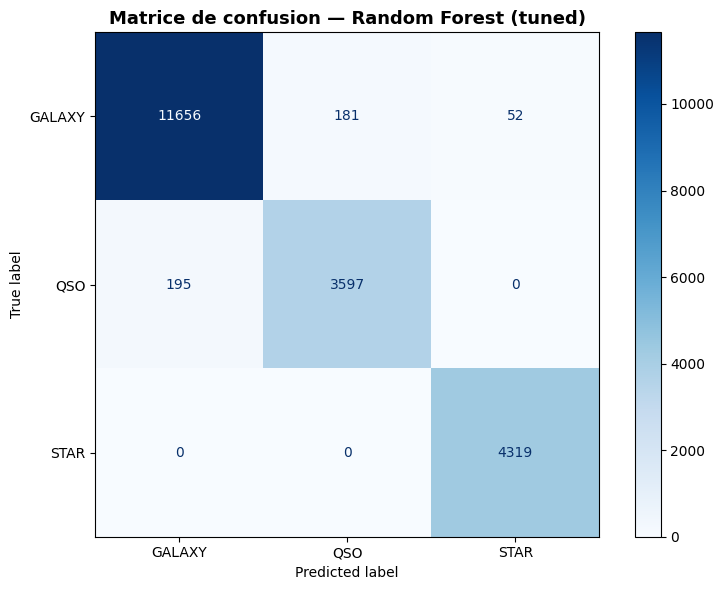

→ Matrice de confusion enregistrée.

Comparaison :
  Accuracy baseline : 0.9786
  Accuracy tuned    : 0.9786
  Gain              : +0.0000


In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
# ÉTAPE 3 — Évaluation du meilleur modèle

y_pred = best_rf.predict(X_test_scaled)

print("\n📊 Rapport de classification (meilleur modèle) :")
print(classification_report(
    y_test,
    y_pred,
    # Remplace les codes 0,1,2 par les vrais noms
    target_names=le.classes_
))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title("Matrice de confusion — Random Forest (tuned)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150)
plt.show()
print("→ Matrice de confusion enregistrée.")

# Comparaison baseline vs tuned
tuned_score = best_rf.score(X_test_scaled, y_test)
print(f"\nComparaison :")
print(f"  Accuracy baseline : {baseline_score:.4f}")
print(f"  Accuracy tuned    : {tuned_score:.4f}")
print(f"  Gain              : +{(tuned_score - baseline_score):.4f}")


## 📊 Matrice de confusion 

La matrice de confusion compare les prédictions du modèle avec les vraies classes.
La **diagonale** représente les bonnes prédictions, le reste sont les erreurs.

La seule confusion notable est entre **GALAXY ↔ QSO** (195 QSO classés comme GALAXY),
ce qui est physiquement cohérent : les quasars sont des noyaux galactiques actifs,
donc spectralement proches des galaxies à certains redshifts.
Les **STAR** sont classifiées parfaitement (0 erreur), grâce au `redshift` ≈ 0
qui les distingue trivialement des deux autres classes.


## 📈 Feature Importance & Impureté de Gini (code est ci-dessous)

L'importance de chaque feature est calculée selon sa contribution moyenne à la
**réduction de l'impureté de Gini** sur l'ensemble des arbres de la forêt.

Le Gini mesure le "désordre" d'un nœud :
- **Gini = 0** → nœud pur (une seule classe)
- **Gini = 0.67** → nœud totalement mélangé (3 classes équiprobables)

À chaque split, l'arbre choisit la feature qui réduit le plus le Gini.
La feature importance est donc la moyenne de ces réductions sur tous les arbres.

> `redshift` domine avec **51.77%** de l'importance totale : il suffit d'un seuil
> sur le redshift pour séparer quasi parfaitement les STARs (redshift ≈ 0)
> du reste, ce qui explique les excellentes performances du modèle sans tuning.


📈 Feature Importances (ordre décroissant) :
   1. redshift     : 0.5177
   2. r-i          : 0.1115
   3. g-r          : 0.0963
   4. u-g          : 0.0822
   5. i-z          : 0.0394
   6. z            : 0.0379
   7. i            : 0.0313
   8. g            : 0.0285
   9. r            : 0.0224
  10. u            : 0.0181
  11. alpha        : 0.0073
  12. delta        : 0.0073


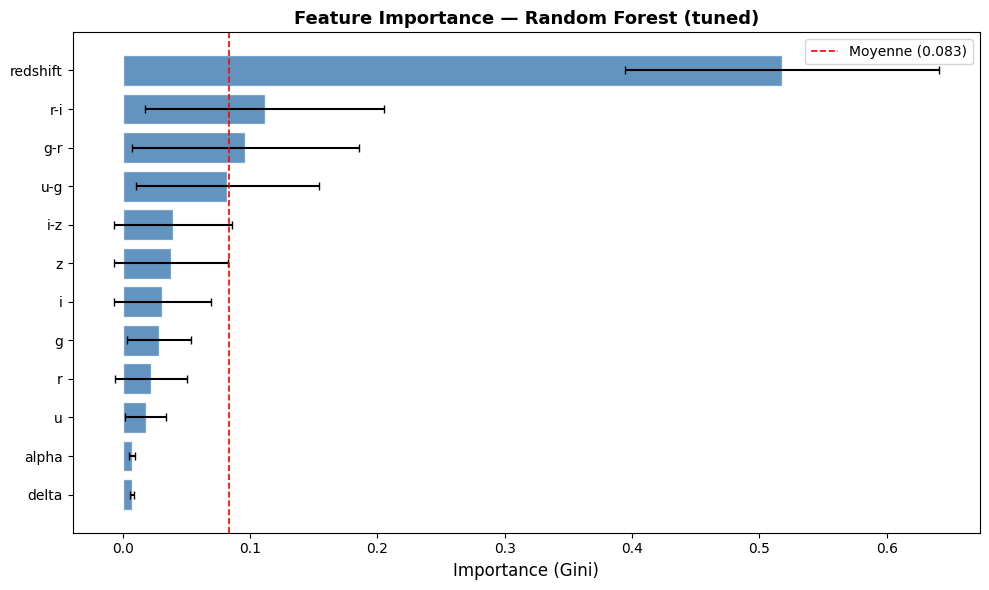

→ Feature importance enregistrée.

✅  SPRINT 2 — Random Forest terminé
  Meilleurs hyperparamètres : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
  Accuracy finale (test)    : 0.9786
  Feature la plus importante: redshift (0.5177)


In [9]:
# ÉTAPE 4 — Feature Importance
# ============================================================
# Le Random Forest calcule l'importance de chaque feature
# selon sa contribution moyenne à la réduction de l'impureté (Gini)

feature_names = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z',
                 'redshift', 'u-g', 'g-r', 'r-i', 'i-z']

# Récupération des importances
importances = best_rf.feature_importances_

# Écart-type des importances entre tous les arbres
# (donne une idée de la stabilité)
std_importances = np.std(
    [tree.feature_importances_ for tree in best_rf.estimators_],
    axis=0
)

# Tri par ordre décroissant
indices = np.argsort(importances)[::-1]
sorted_features    = [feature_names[i] for i in indices]
sorted_importances = importances[indices]
sorted_std         = std_importances[indices]

print("\n📈 Feature Importances (ordre décroissant) :")
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importances)):
    print(f"  {i+1:2}. {feat:<12} : {imp:.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    sorted_features[::-1],
    sorted_importances[::-1],
    xerr=sorted_std[::-1],
    color='steelblue',
    edgecolor='white',
    capsize=3,
    alpha=0.85
)

ax.set_xlabel("Importance (Gini)", fontsize=12)
ax.set_title("Feature Importance — Random Forest (tuned)",
             fontsize=13, fontweight='bold')
ax.axvline(x=importances.mean(), color='red', linestyle='--',
           linewidth=1.2, label=f'Moyenne ({importances.mean():.3f})')
ax.legend()
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=150)
plt.show()
print("→ Feature importance enregistrée.")

# ============================================================
# ÉTAPE 5 — Récapitulatif final Sprint 2
# ============================================================
print("\n" + "="*55)
print("✅  SPRINT 2 — Random Forest terminé")
print("="*55)
print(f"  Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"  Accuracy finale (test)    : {tuned_score:.4f}")
print(f"  Feature la plus importante: {sorted_features[0]} ({sorted_importances[0]:.4f})")
print("="*55)

## 📝 Analyse des résultats — Sprint 2 - Brice

Le Grid Search confirme que les hyperparamètres par défaut de scikit-learn sont déjà
proches de l'optimal pour ce dataset. L'absence de gain significatif s'explique par
la forte puissance discriminante du `redshift`, qui à lui seul représente **~52%**
de l'importance totale, rendant le modèle peu sensible au fine-tuning.

### Meilleurs hyperparamètres trouvés
| Hyperparamètre | Valeur | Valeur par défaut sklearn |
|---                  |---     |---        |
| `max_depth`         | `None` | `None` ✅ |
| `max_features`      | `sqrt` | `sqrt` ✅ |
| `min_samples_split` | `2`    | `2`    ✅ |
| `n_estimators`      | `300`  | `100`  ⬆️ |
 
> Le Grid Search a donc simplement confirmé les valeurs par défaut,
> à l'exception du nombre d'arbres (300 vs 100), sans impact mesurable sur l'accuracy.

### Scores
| Métrique                               | Valeur |
|---                                     |---         |
| Accuracy baseline (100 arbres)         | **0.9786** |
| Meilleur score CV Grid Search          | **0.9818** |
| Accuracy finale (300 arbres, test set) | **0.9786** |

> ⚠️ Le score CV (0.9818) est légèrement supérieur au score test (0.9786) car il est
> calculé sur les données **SMOTE** (synthétiques), donc un peu plus faciles à classifier.
> Le test set étant 100% réel, un léger écart est normal et attendu.

### Feature la plus importante
`redshift` — **0.5177** (51.77% de l'importance totale)

In [10]:
# ============================================================
# SPRINT 2 — XGBoost
# Classification d'objets célestes — SDSS17
# ============================================================
# Prérequis (variables du Sprint 1) :
#   X_train_resampled, y_train_resampled
#   X_test_scaled, y_test
#   le  (LabelEncoder)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import time

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize


In [11]:


# ============================================================
# ÉTAPE 1 — Baseline XGBoost (sans tuning)
# ============================================================

xgb_baseline = XGBClassifier(
    # Nombre d'arbres
    n_estimators=100,
    # Graine pour la reproductibilité
    random_state=42,
    # Supprime les warnings inutiles
    eval_metric='mlogloss',
    # Utilise tous les coeurs
    n_jobs=-1
)

xgb_baseline.fit(X_train_resampled, y_train_resampled)

# Score sur le test set (données jamais vues)
baseline_score = xgb_baseline.score(X_test_scaled, y_test)
print(f"Accuracy baseline (sans tuning) : {baseline_score:.4f}")



Accuracy baseline (sans tuning) : 0.9769


In [12]:

# ============================================================
# ÉTAPE 2 — Random Search pour optimiser les hyperparamètres
# ============================================================

param_dist = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.8, 1.0],
}

# 10 combinaisons aléatoires × 3 folds = 30 entraînements
# au lieu de 54 × 3 = 162 avec GridSearchCV
print(f"\nNombre de combinaisons à tester : 10 (aléatoires sur {3*3*3*2} possibles)")

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,        # nombre de combinaisons testées
    cv=3,             # validation croisée à 3 folds
    n_jobs=4,         # 4 coeurs pour éviter de surcharger la machine
    verbose=2,
    scoring='f1_macro',  # F1 macro car classes déséquilibrées
    random_state=42      # reproductibilité du tirage aléatoire
)

model_path = "best_xgb_model.pkl"

if os.path.exists(model_path):
    print("✅ Modèle chargé depuis le fichier (pas de réentraînement)")
    best_xgb    = joblib.load(model_path)
    best_params = "chargé depuis fichier (params inconnus)"
    best_score  = best_xgb.score(X_test_scaled, y_test)
else:
    print("⏳ Random Search en cours (quelques minutes)...")
    t0 = time.time()
    random_search.fit(X_train_resampled, y_train_resampled)
    best_xgb    = random_search.best_estimator_
    best_params = random_search.best_params_
    best_score  = random_search.best_score_
    joblib.dump(best_xgb, model_path)
    print(f"💾 Modèle sauvegardé dans {model_path} ({time.time()-t0:.0f}s)")

# Meilleurs hyperparamètres trouvés
print("\n" + "="*50)
print("✅ Meilleurs hyperparamètres :")
print(best_params)
print(f"Meilleur score CV (F1 macro) : {best_score:.4f}")
print("="*50)




Nombre de combinaisons à tester : 10 (aléatoires sur 54 possibles)
⏳ Random Search en cours (quelques minutes)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   3.2s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   3.6s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   3.6s
[CV] END learning_rate=0.2, max_depth=7, n_estimators=100, subsample=1.0; total time=   5.5s
[CV] END learning_rate=0.2, max_depth=7, n_estimators=100, subsample=1.0; total time=   6.0s
[CV] END learning_rate=0.2, max_depth=7, n_estimators=100, subsample=0.8; total time=   5.9s
[CV] END learning_rate=0.2, max_depth=7, n_estimators=100, subsample=1.0; total time=   6.3s
[CV] END learning_rate=0.2, max_depth=7, n_estimators=100, subsample=0.8; total time=   6.4s
[CV] END learning_rate=0.05, max_depth=7, n_estimators=100, subsample=0.8; total


📊 Rapport de classification (meilleur modèle) :
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO       0.95      0.95      0.95      3792
        STAR       0.99      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



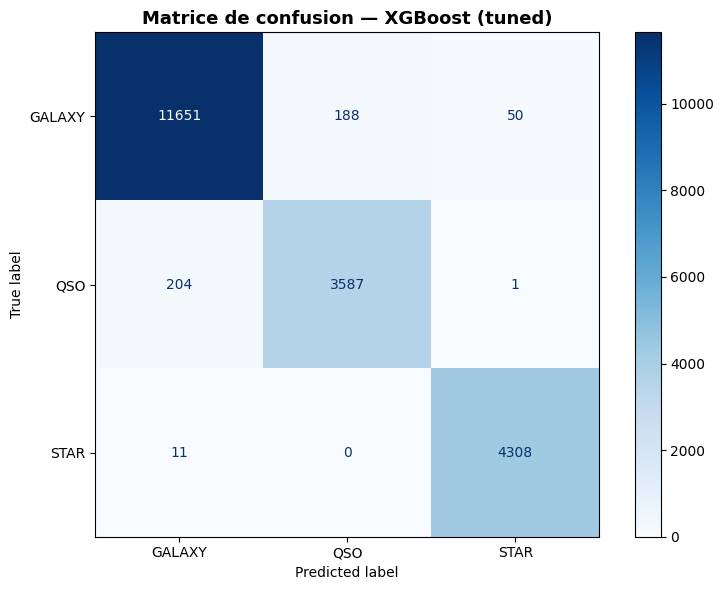

→ Matrice de confusion enregistrée.

Comparaison :
  Accuracy baseline : 0.9769
  Accuracy tuned    : 0.9773
  Gain              : +0.0003

  F1 macro         : 0.9739
  F1 weighted      : 0.9773
  AUC-ROC (OvR)    : 0.9962

  F1 par classe :
    GALAXY   : 0.9809
    QSO      : 0.9481
    STAR     : 0.9929

📦 xgb_results prêt pour Sprint 4 : {'model': 'XGBoost', 'accuracy': 0.9773, 'f1_macro': 0.9739, 'f1_weighted': 0.9773, 'auc_roc': 0.9962, 'f1_per_class': {'GALAXY': np.float64(0.9809), 'QSO': np.float64(0.9481), 'STAR': np.float64(0.9929)}, 'best_params': {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2}, 'cv_f1_macro': np.float64(0.9838)}


In [13]:

# ============================================================
# ÉTAPE 3 — Évaluation du meilleur modèle
# ============================================================

y_pred      = best_xgb.predict(X_test_scaled)
y_pred_prob = best_xgb.predict_proba(X_test_scaled)   # nécessaire pour AUC-ROC

print("\n📊 Rapport de classification (meilleur modèle) :")
print(classification_report(
    y_test,
    y_pred,
    # Remplace les codes 0,1,2 par les vrais noms
    target_names=le.classes_
))

# --- Matrice de confusion ---
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title("Matrice de confusion — XGBoost (tuned)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix_xgb.png", dpi=150)
plt.show()
print("→ Matrice de confusion enregistrée.")

# --- Comparaison baseline vs tuned ---
tuned_score = best_xgb.score(X_test_scaled, y_test)
print(f"\nComparaison :")
print(f"  Accuracy baseline : {baseline_score:.4f}")
print(f"  Accuracy tuned    : {tuned_score:.4f}")
print(f"  Gain              : +{(tuned_score - baseline_score):.4f}")

# --- Métriques complètes pour Sarah (évaluation Sprint 4) ---
f1_macro     = f1_score(y_test, y_pred, average='macro')
f1_weighted  = f1_score(y_test, y_pred, average='weighted')
f1_per_class = f1_score(y_test, y_pred, average=None)

y_test_bin   = label_binarize(y_test, classes=[0, 1, 2])
auc_roc      = roc_auc_score(y_test_bin, y_pred_prob,
                              multi_class='ovr', average='macro')

print(f"\n  F1 macro         : {f1_macro:.4f}")
print(f"  F1 weighted      : {f1_weighted:.4f}")
print(f"  AUC-ROC (OvR)    : {auc_roc:.4f}")
print(f"\n  F1 par classe :")
for name, score in zip(le.classes_, f1_per_class):
    print(f"    {name:<8} : {score:.4f}")

# Dictionnaire prêt pour le tableau comparatif Sprint 4
xgb_results = {
    'model'       : 'XGBoost',
    'accuracy'    : round(tuned_score,   4),
    'f1_macro'    : round(f1_macro,      4),
    'f1_weighted' : round(f1_weighted,   4),
    'auc_roc'     : round(auc_roc,       4),
    'f1_per_class': {n: round(s, 4) for n, s in zip(le.classes_, f1_per_class)},
    'best_params' : best_params,
    'cv_f1_macro' : round(best_score,    4),
}
print("\n📦 xgb_results prêt pour Sprint 4 :", xgb_results)




📈 Feature Importances (ordre décroissant) :
   1. redshift     : 0.6556
   2. r-i          : 0.1618
   3. g            : 0.0548
   4. g-r          : 0.0275
   5. u-g          : 0.0266
   6. u            : 0.0141
   7. i            : 0.0126
   8. z            : 0.0112
   9. r            : 0.0101
  10. i-z          : 0.0095
  11. delta        : 0.0085
  12. alpha        : 0.0078


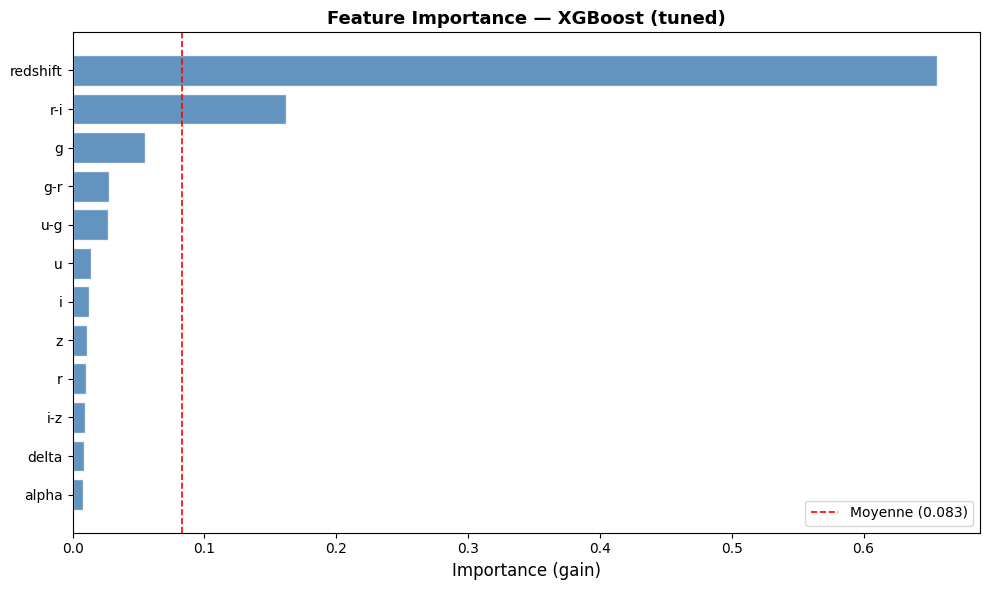

→ Feature importance enregistrée.


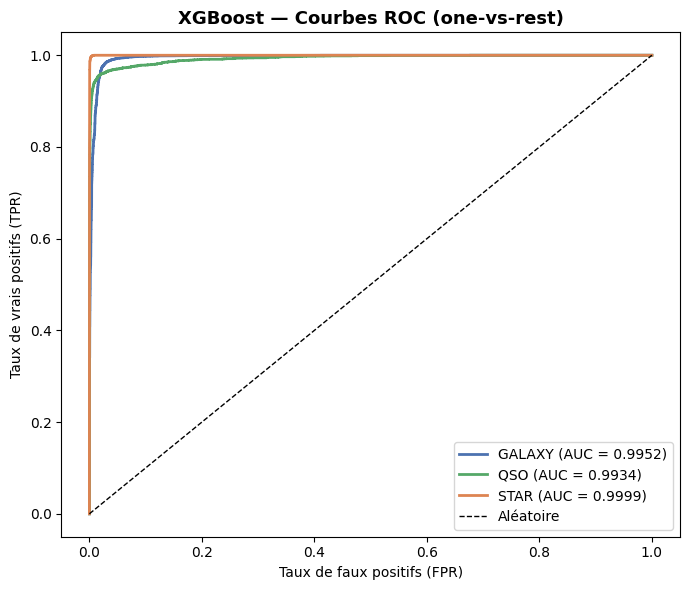

→ Courbes ROC enregistrées.


In [14]:

# ============================================================
# ÉTAPE 4 — Feature Importance
# ============================================================
# XGBoost mesure l'importance de chaque feature
# selon le gain moyen apporté à chaque split qui l'utilise

feature_names = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z',
                 'redshift', 'u-g', 'g-r', 'r-i', 'i-z']

importances = best_xgb.feature_importances_

# Tri par ordre décroissant
indices            = np.argsort(importances)[::-1]
sorted_features    = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

print("\n📈 Feature Importances (ordre décroissant) :")
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importances)):
    print(f"  {i+1:2}. {feat:<12} : {imp:.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    sorted_features[::-1],
    sorted_importances[::-1],
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

ax.set_xlabel("Importance (gain)", fontsize=12)
ax.set_title("Feature Importance — XGBoost (tuned)",
             fontsize=13, fontweight='bold')
ax.axvline(x=importances.mean(), color='red', linestyle='--',
           linewidth=1.2, label=f'Moyenne ({importances.mean():.3f})')
ax.legend()
plt.tight_layout()
plt.savefig("feature_importance_xgb.png", dpi=150)
plt.show()
print("→ Feature importance enregistrée.")

# --- Courbes ROC ---
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#4C72B0', '#55A868', '#DD8452']

for i, (name, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_i:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
ax.set_xlabel("Taux de faux positifs (FPR)")
ax.set_ylabel("Taux de vrais positifs (TPR)")
ax.set_title("XGBoost — Courbes ROC (one-vs-rest)", fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("roc_curves_xgb.png", dpi=150)
plt.show()
print("→ Courbes ROC enregistrées.")



In [15]:

# ============================================================
# ÉTAPE 5 — Récapitulatif final Sprint 2
# ============================================================

print("\n" + "="*55)
print("✅  SPRINT 2 — XGBoost terminé")
print("="*55)
print(f"  Meilleurs hyperparamètres : {best_params}")
print(f"  Accuracy finale (test)    : {tuned_score:.4f}")
print(f"  F1 macro (test)           : {f1_macro:.4f}")
print(f"  AUC-ROC (test)            : {auc_roc:.4f}")
print(f"  Feature la plus importante: {sorted_features[0]} ({sorted_importances[0]:.4f})")
print("="*55)
print("\n📦 Transmettre pour fin sprint2 : xgb_results")


✅  SPRINT 2 — XGBoost terminé
  Meilleurs hyperparamètres : {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2}
  Accuracy finale (test)    : 0.9773
  F1 macro (test)           : 0.9739
  AUC-ROC (test)            : 0.9962
  Feature la plus importante: redshift (0.6556)

📦 Transmettre pour fin sprint2 : xgb_results


TABLEAU COMPARATIF DES PERFORMANCES
Métrique             Random Forest        XGBoost              Écart          
---------------------------------------------------------------------------
Accuracy             0.9786               0.9773               -0.0013
F1 macro             0.9754               0.9739               -0.0015
F1 weighted          0.9786               0.9773               -0.0013
AUC-ROC macro        0.9965               0.9962               -0.0003

F1-SCORE PAR CLASSE
----------------------------------------------------------------------
Classe          Random Forest        XGBoost              Diff           
GALAXY          0.9820               0.9809               -0.0010
QSO             0.9503               0.9481               -0.0023
STAR            0.9940               0.9929               -0.0012


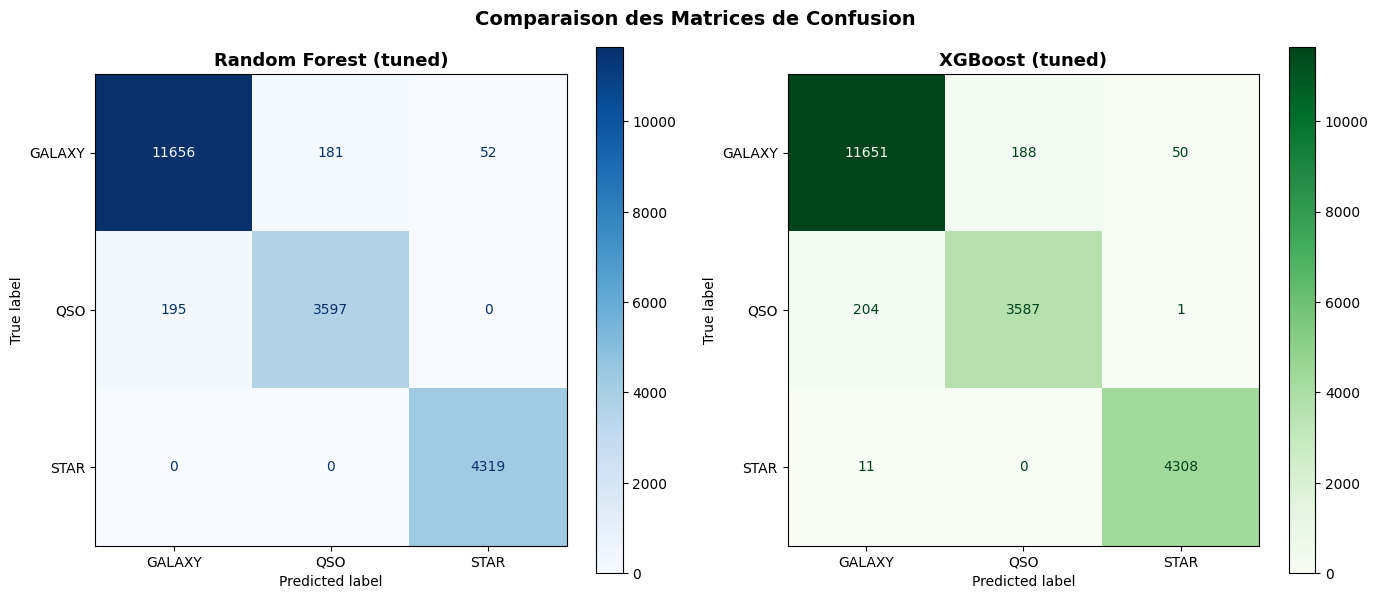

→ Matrices de confusion sauvegardées.


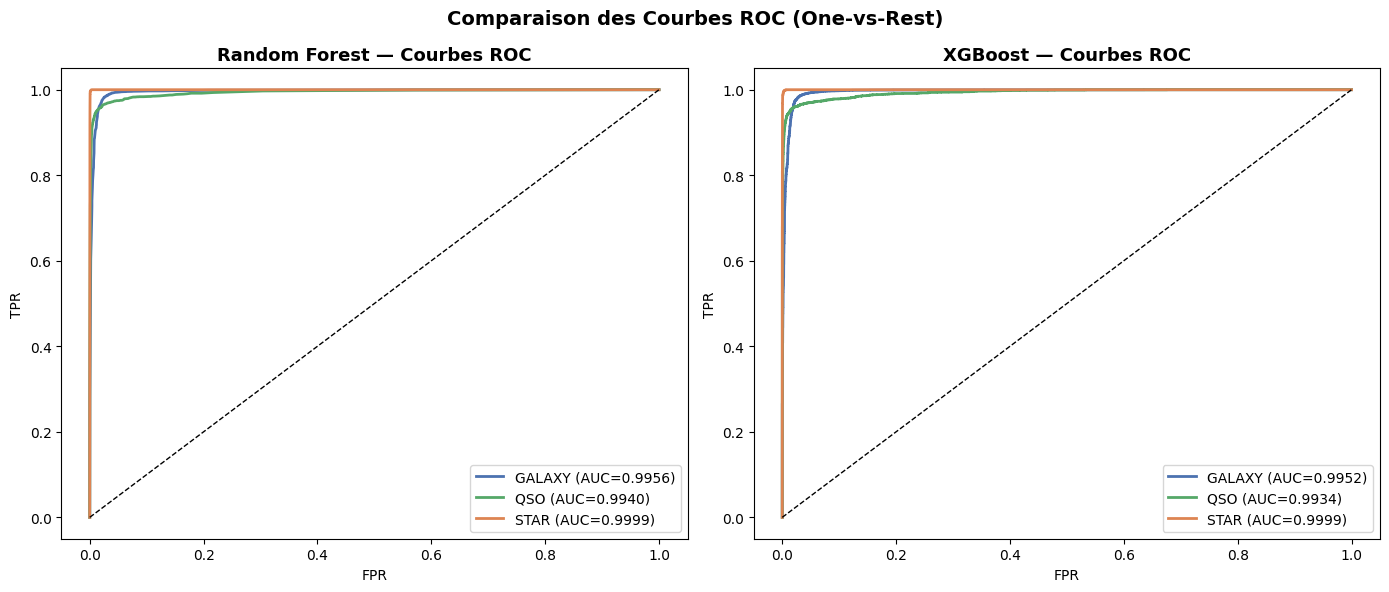

→ Courbes ROC sauvegardées.
→ Résultats sauvegardés dans ml_comparison_results.json

✅  SPRINT 2 — PARTIE C terminée


In [16]:
# ============================================================
# SPRINT 2 — PARTIE C : Évaluation comparative RF vs XGBoost
# Auteur : TOBOSSI Sarah
# ============================================================

import json
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import label_binarize

# Prédictions des deux modèles
y_pred_rf  = best_rf.predict(X_test_scaled)
y_pred_xgb = best_xgb.predict(X_test_scaled)

# Probabilités pour AUC-ROC
y_proba_rf  = best_rf.predict_proba(X_test_scaled)
y_proba_xgb = best_xgb.predict_proba(X_test_scaled)

# Binarisation pour multi-classes
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Métriques
acc_rf  = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

f1_macro_rf  = f1_score(y_test, y_pred_rf,  average='macro')
f1_macro_xgb = f1_score(y_test, y_pred_xgb, average='macro')

f1_weighted_rf  = f1_score(y_test, y_pred_rf,  average='weighted')
f1_weighted_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

f1_per_class_rf  = f1_score(y_test, y_pred_rf,  average=None)
f1_per_class_xgb = f1_score(y_test, y_pred_xgb, average=None)

auc_rf  = roc_auc_score(y_test_bin, y_proba_rf,  multi_class='ovr', average='macro')
auc_xgb = roc_auc_score(y_test_bin, y_proba_xgb, multi_class='ovr', average='macro')

class_names = le.classes_

# Tableau comparatif
print("=" * 75)
print("TABLEAU COMPARATIF DES PERFORMANCES")
print("=" * 75)
print(f"{'Métrique':<20} {'Random Forest':<20} {'XGBoost':<20} {'Écart':<15}")
print("-" * 75)
print(f"{'Accuracy':<20} {acc_rf:<20.4f} {acc_xgb:<20.4f} {acc_xgb - acc_rf:+.4f}")
print(f"{'F1 macro':<20} {f1_macro_rf:<20.4f} {f1_macro_xgb:<20.4f} {f1_macro_xgb - f1_macro_rf:+.4f}")
print(f"{'F1 weighted':<20} {f1_weighted_rf:<20.4f} {f1_weighted_xgb:<20.4f} {f1_weighted_xgb - f1_weighted_rf:+.4f}")
print(f"{'AUC-ROC macro':<20} {auc_rf:<20.4f} {auc_xgb:<20.4f} {auc_xgb - auc_rf:+.4f}")

print("\nF1-SCORE PAR CLASSE")
print("-" * 70)
print(f"{'Classe':<15} {'Random Forest':<20} {'XGBoost':<20} {'Diff':<15}")
for i, name in enumerate(class_names):
    diff = f1_per_class_xgb[i] - f1_per_class_rf[i]
    print(f"{name:<15} {f1_per_class_rf[i]:<20.4f} {f1_per_class_xgb[i]:<20.4f} {diff:+.4f}")

# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_rf  = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

ConfusionMatrixDisplay(cm_rf,  display_labels=class_names).plot(ax=axes[0], cmap='Blues',  values_format='d')
ConfusionMatrixDisplay(cm_xgb, display_labels=class_names).plot(ax=axes[1], cmap='Greens', values_format='d')

axes[0].set_title('Random Forest (tuned)', fontsize=13, fontweight='bold')
axes[1].set_title('XGBoost (tuned)',        fontsize=13, fontweight='bold')

plt.suptitle('Comparaison des Matrices de Confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150)
plt.show()
print("→ Matrices de confusion sauvegardées.")

# Courbes ROC côte à côte
colors = ['#4C72B0', '#55A868', '#DD8452']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_rf[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_proba_rf[:, i])
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_i:.4f})')

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_title('Random Forest — Courbes ROC', fontsize=13, fontweight='bold')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend(loc='lower right')

for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_xgb[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_proba_xgb[:, i])
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_i:.4f})')

axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_title('XGBoost — Courbes ROC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

plt.suptitle('Comparaison des Courbes ROC (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150)
plt.show()
print("→ Courbes ROC sauvegardées.")

# Sauvegarde JSON pour Sprint 4
ml_comparison_results = {
    'random_forest': {
        'accuracy':    round(acc_rf, 4),
        'f1_macro':    round(f1_macro_rf, 4),
        'f1_weighted': round(f1_weighted_rf, 4),
        'auc_roc':     round(auc_rf, 4),
    },
    'xgboost': {
        'accuracy':    round(acc_xgb, 4),
        'f1_macro':    round(f1_macro_xgb, 4),
        'f1_weighted': round(f1_weighted_xgb, 4),
        'auc_roc':     round(auc_xgb, 4),
    }
}
with open('ml_comparison_results.json', 'w', encoding='utf-8') as f:
    json.dump(ml_comparison_results, f, indent=2)
print("→ Résultats sauvegardés dans ml_comparison_results.json")

print("\n" + "="*55)
print("✅  SPRINT 2 — PARTIE C terminée")
print("="*55)

In [17]:
# ============================================================
# SPRINT 3 — PARTIE B1 : Architecture MLP & Dropout
# Auteur : TOBOSSI Sarah
# ============================================================

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    # 3 couches cachées : 128 → 64 → 32 neurones
    hidden_layer_sizes=(128, 64, 32),
    # Fonction d'activation ReLU
    activation='relu',
    # Optimiseur Adam
    solver='adam',
    learning_rate_init=0.001,
    learning_rate='adaptive',
    # Régularisation L2 (équivalent Dropout en sklearn)
    alpha=0.0001,
    batch_size=32,
    max_iter=100,
    shuffle=True,
    # Early stopping
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=False
)

print("📐 ARCHITECTURE MLP :")
print("   Entrée       : 12 neurones (features)")
print("   Dense 1      : 128 neurones (ReLU) + L2")
print("   Dense 2      :  64 neurones (ReLU) + L2")
print("   Dense 3      :  32 neurones (ReLU)")
print("   Sortie       :   3 neurones (Softmax) → GALAXY / QSO / STAR")
print("\n✅ Architecture MLP définie → passer à B2")

📐 ARCHITECTURE MLP :
   Entrée       : 12 neurones (features)
   Dense 1      : 128 neurones (ReLU) + L2
   Dense 2      :  64 neurones (ReLU) + L2
   Dense 3      :  32 neurones (ReLU)
   Sortie       :   3 neurones (Softmax) → GALAXY / QSO / STAR

✅ Architecture MLP définie → passer à B2


✅ MLP chargé depuis le fichier (pas de réentraînement)


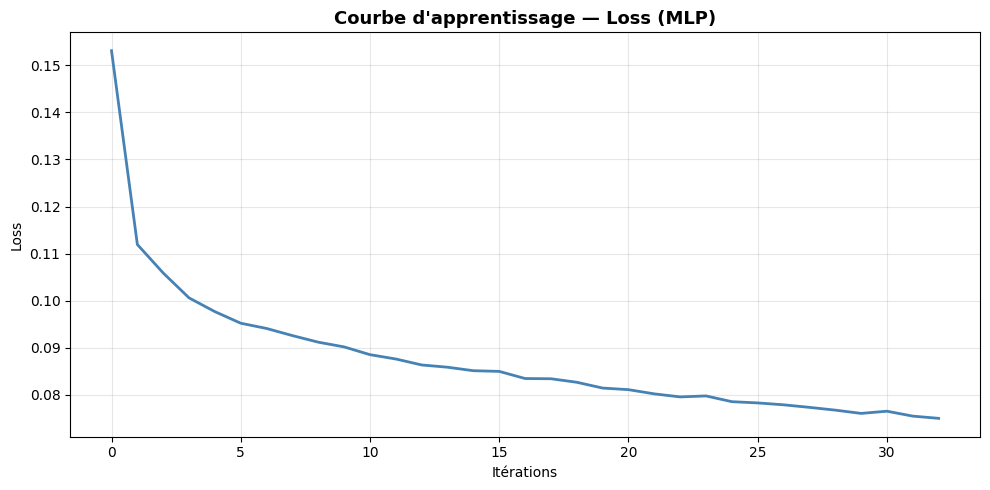

→ Courbe de loss sauvegardée.


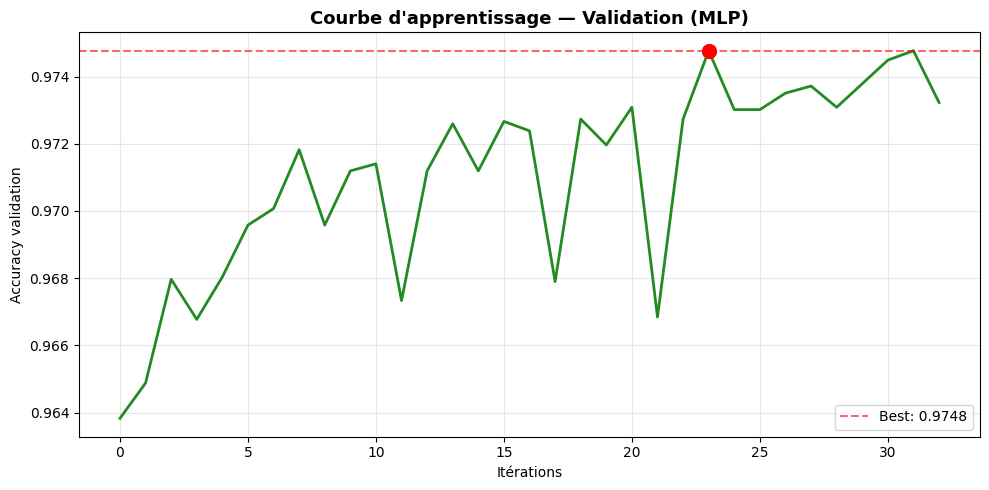

→ Meilleur score validation : 0.9748 (itération 24)

✅  SPRINT 3 — PARTIE B terminée


In [20]:
# ============================================================
# SPRINT 3 — PARTIE B2 : Entraînement & Courbes d'apprentissage
# Auteur : TOBOSSI Sarah
# ============================================================

import time

mlp_path = "mlp_model_sprint3.pkl"

if os.path.exists(mlp_path):
    print("✅ MLP chargé depuis le fichier (pas de réentraînement)")
    mlp = joblib.load(mlp_path)

else:
    print("⏳ Entraînement du MLP...")
    start_time = time.time()
    mlp.fit(X_train_resampled, y_train_resampled)
    training_time = time.time() - start_time

    joblib.dump(mlp, mlp_path)
    print(f"✅ Entraînement terminé en {training_time:.2f}s")
    print(f"   Itérations : {mlp.n_iter_}")
    print(f"   Loss finale : {mlp.loss_:.6f}")
    print(f"💾 Modèle sauvegardé dans {mlp_path}")

# Courbe de loss
if hasattr(mlp, 'loss_curve_'):
    plt.figure(figsize=(10, 5))
    plt.plot(mlp.loss_curve_, linewidth=2, color='steelblue')
    plt.xlabel('Itérations')
    plt.ylabel('Loss')
    plt.title("Courbe d'apprentissage — Loss (MLP)", fontsize=13, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('mlp_loss_curve.png', dpi=150)
    plt.show()
    print("→ Courbe de loss sauvegardée.")

# Courbe de validation
if hasattr(mlp, 'validation_scores_') and len(mlp.validation_scores_) > 0:
    best_score = max(mlp.validation_scores_)
    best_iter  = mlp.validation_scores_.index(best_score)

    plt.figure(figsize=(10, 5))
    plt.plot(mlp.validation_scores_, linewidth=2, color='forestgreen')
    plt.axhline(y=best_score, color='red', linestyle='--', alpha=0.6, label=f'Best: {best_score:.4f}')
    plt.scatter(best_iter, best_score, color='red', s=100, zorder=5)
    plt.xlabel('Itérations')
    plt.ylabel('Accuracy validation')
    plt.title("Courbe d'apprentissage — Validation (MLP)", fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('mlp_validation_curve.png', dpi=150)
    plt.show()
    print(f"→ Meilleur score validation : {best_score:.4f} (itération {best_iter+1})")

print("\n" + "="*55)
print("✅  SPRINT 3 — PARTIE B terminée")
print("="*55)

📊 Rapport de classification (MLP) :
              precision    recall  f1-score   support

      GALAXY       0.98      0.96      0.97     11889
         QSO       0.92      0.95      0.94      3792
        STAR       0.97      1.00      0.98      4319

    accuracy                           0.97     20000
   macro avg       0.96      0.97      0.96     20000
weighted avg       0.97      0.97      0.97     20000



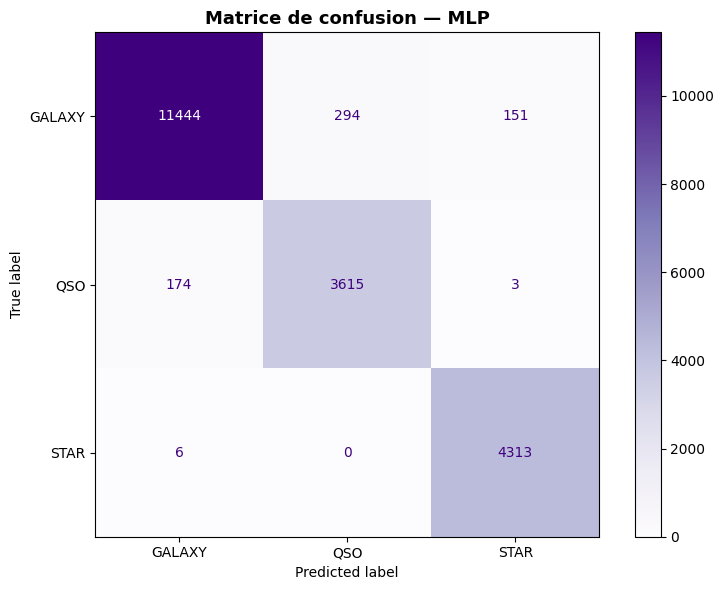

→ Matrice de confusion MLP sauvegardée.


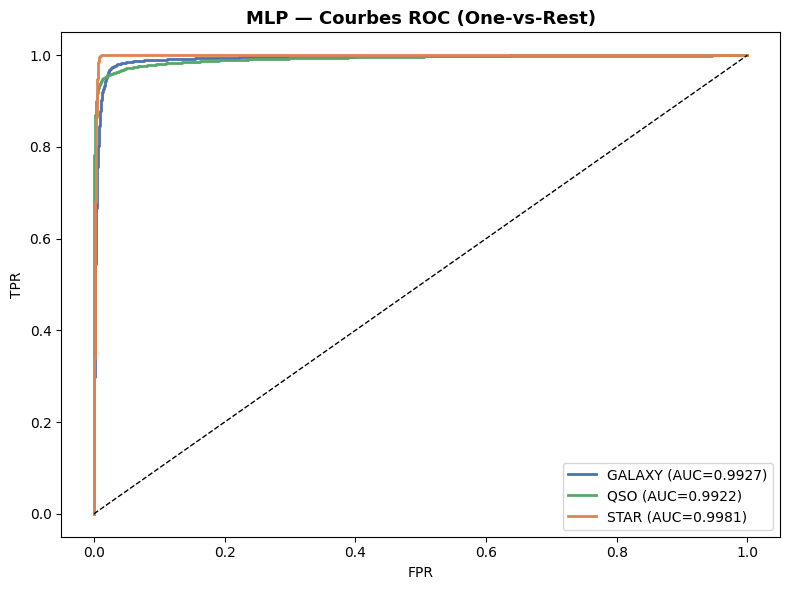

→ Courbes ROC MLP sauvegardées.

✅  SPRINT 3 — Résultats DL
  Accuracy : 0.9686
  F1 macro : 0.9647
  AUC-ROC  : 0.9943


In [21]:
# ============================================================
# SPRINT 3 — PARTIE C : Évaluation du MLP
# ============================================================

y_pred_mlp    = mlp.predict(X_test_scaled)
y_proba_mlp   = mlp.predict_proba(X_test_scaled)
y_test_bin    = label_binarize(y_test, classes=[0, 1, 2])

acc_mlp          = accuracy_score(y_test, y_pred_mlp)
f1_macro_mlp     = f1_score(y_test, y_pred_mlp, average='macro')
f1_weighted_mlp  = f1_score(y_test, y_pred_mlp, average='weighted')
f1_per_class_mlp = f1_score(y_test, y_pred_mlp, average=None)
auc_mlp          = roc_auc_score(y_test_bin, y_proba_mlp, multi_class='ovr', average='macro')

# Rapport de classification
print("📊 Rapport de classification (MLP) :")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

# Matrice de confusion
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_mlp, display_labels=le.classes_).plot(ax=ax, cmap='Purples', values_format='d')
ax.set_title('Matrice de confusion — MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_mlp.png', dpi=150)
plt.show()
print("→ Matrice de confusion MLP sauvegardée.")

# Courbes ROC
colors = ['#4C72B0', '#55A868', '#DD8452']
fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_mlp[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_proba_mlp[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_i:.4f})')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('MLP — Courbes ROC (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves_mlp.png', dpi=150)
plt.show()
print("→ Courbes ROC MLP sauvegardées.")

print("\n" + "="*55)
print("✅  SPRINT 3 — Résultats DL")
print("="*55)
print(f"  Accuracy : {acc_mlp:.4f}")
print(f"  F1 macro : {f1_macro_mlp:.4f}")
print(f"  AUC-ROC  : {auc_mlp:.4f}")
print("="*55)

In [24]:
# ============================================================
# SPRINT 4 — PARTIE A : Tableau comparatif ML vs DL
# ============================================================

comparison_data = {
    'Modèle':      ['Random Forest', 'XGBoost', 'MLP'],
    'Accuracy':    [acc_rf,          acc_xgb,   acc_mlp],
    'F1 macro':    [f1_macro_rf,     f1_macro_xgb,  f1_macro_mlp],
    'F1 weighted': [f1_weighted_rf,  f1_weighted_xgb, f1_weighted_mlp],
    'AUC-ROC':     [auc_rf,          auc_xgb,   auc_mlp],
}

df_comparison = pd.DataFrame(comparison_data).set_index('Modèle')

print("=" * 65)
print("TABLEAU COMPARATIF — ML vs Deep Learning")
print("=" * 65)
print(df_comparison.to_string(float_format='{:.4f}'.format))
print("=" * 65)

print("\n🏆 Meilleur modèle par métrique :")
for col in df_comparison.columns:
    best = df_comparison[col].idxmax()
    print(f"  {col:<15} → {best} ({df_comparison[col].max():.4f})")

df_comparison.to_csv('final_comparison_table.csv')
print("\n→ Tableau sauvegardé dans final_comparison_table.csv")

TABLEAU COMPARATIF — ML vs Deep Learning
               Accuracy  F1 macro  F1 weighted  AUC-ROC
Modèle                                                 
Random Forest    0.9786    0.9754       0.9786   0.9965
XGBoost          0.9773    0.9739       0.9773   0.9962
MLP              0.9686    0.9647       0.9687   0.9943

🏆 Meilleur modèle par métrique :
  Accuracy        → Random Forest (0.9786)
  F1 macro        → Random Forest (0.9754)
  F1 weighted     → Random Forest (0.9786)
  AUC-ROC         → Random Forest (0.9965)

→ Tableau sauvegardé dans final_comparison_table.csv


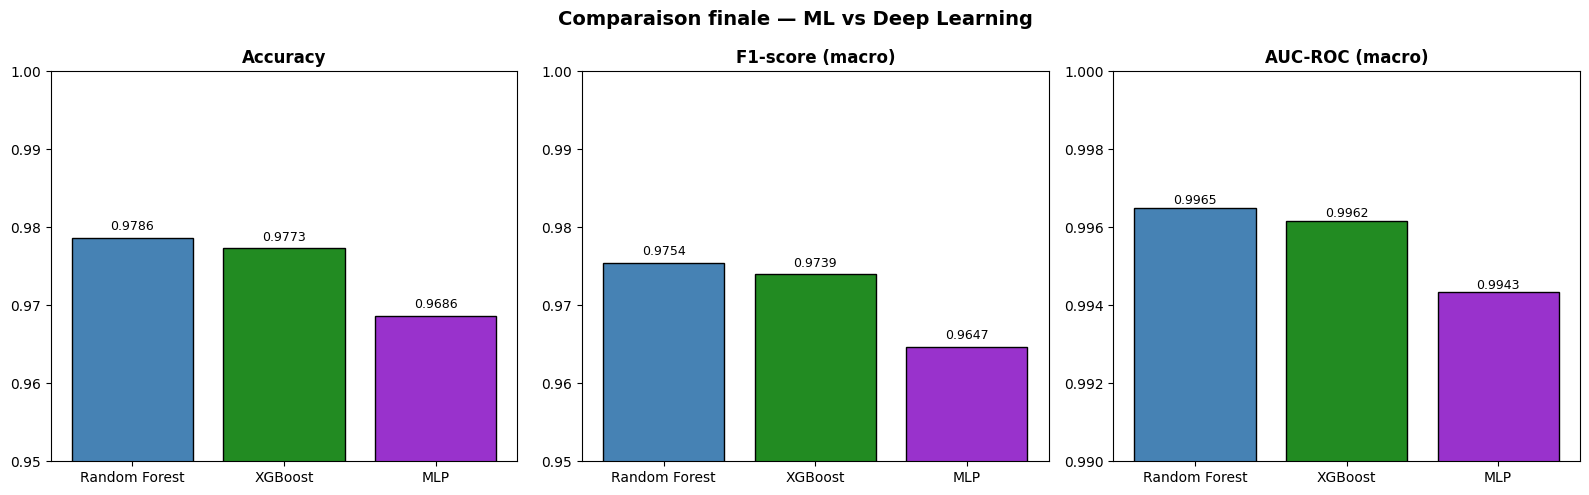

→ Visualisations finales sauvegardées.


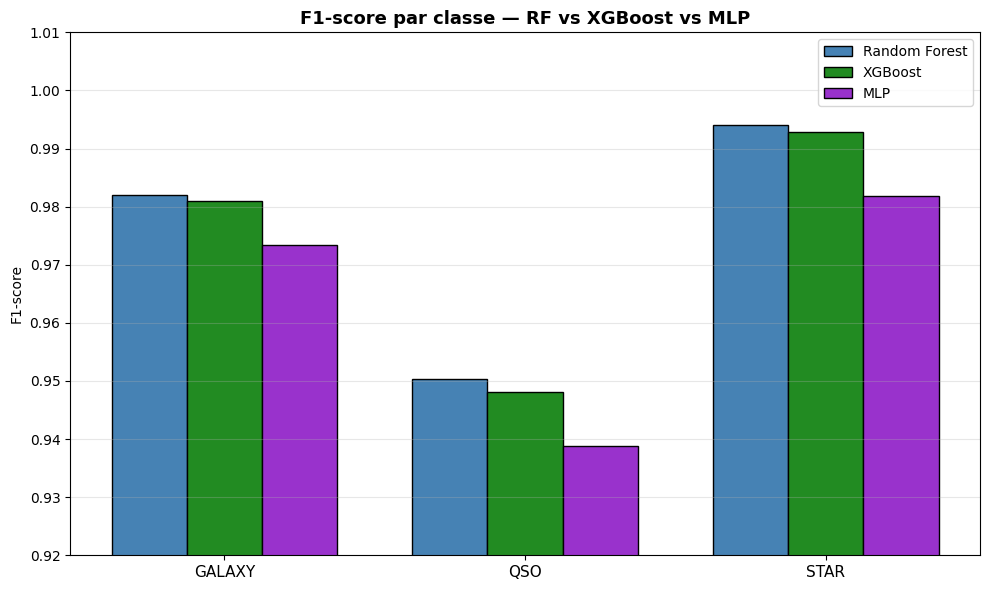

→ F1 par classe sauvegardé.


In [25]:
# ============================================================
# SPRINT 4 — PARTIE B : Visualisations finales
# ============================================================

models     = ['Random Forest', 'XGBoost', 'MLP']
accuracies = [acc_rf,      acc_xgb,  acc_mlp]
f1_macros  = [f1_macro_rf, f1_macro_xgb, f1_macro_mlp]
aucs       = [auc_rf,      auc_xgb,  auc_mlp]
colors_bar = ['steelblue', 'forestgreen', 'darkorchid']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
axes[0].bar(models, accuracies, color=colors_bar, edgecolor='black')
axes[0].set_title('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_ylim(0.95, 1.0)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

# F1 macro
axes[1].bar(models, f1_macros, color=colors_bar, edgecolor='black')
axes[1].set_title('F1-score (macro)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0.95, 1.0)
for i, v in enumerate(f1_macros):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

# AUC-ROC
axes[2].bar(models, aucs, color=colors_bar, edgecolor='black')
axes[2].set_title('AUC-ROC (macro)', fontsize=12, fontweight='bold')
axes[2].set_ylim(0.99, 1.0)
for i, v in enumerate(aucs):
    axes[2].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Comparaison finale — ML vs Deep Learning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_barplots_comparison.png', dpi=150)
plt.show()
print("→ Visualisations finales sauvegardées.")

# F1 par classe — les 3 modèles
x = np.arange(len(le.classes_))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, f1_per_class_rf,  width, label='Random Forest', color='steelblue',   edgecolor='black')
ax.bar(x,         f1_per_class_xgb, width, label='XGBoost',       color='forestgreen', edgecolor='black')
ax.bar(x + width, f1_per_class_mlp, width, label='MLP',           color='darkorchid',  edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(le.classes_, fontsize=11)
ax.set_ylabel('F1-score')
ax.set_title('F1-score par classe — RF vs XGBoost vs MLP', fontsize=13, fontweight='bold')
ax.set_ylim(0.92, 1.01)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('f1_per_class_final.png', dpi=150)
plt.show()
print("→ F1 par classe sauvegardé.")